model de iti ghiceste ce fel de haina e in imagine

lets goo

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5), (0.5))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)




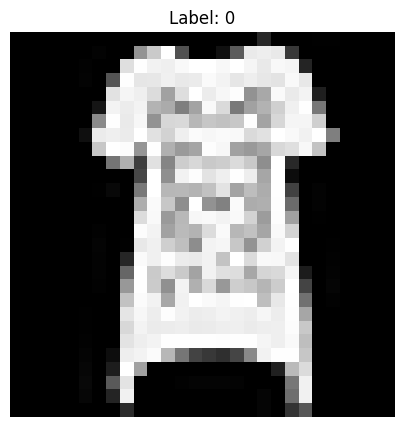

In [15]:
import matplotlib.pyplot as plt

dataiter = iter(train_loader)
images, labels = next(dataiter)

img = images[0]
label = labels[0].item()

plt.figure(figsize=(5, 5))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


In [16]:
import torch.nn.functional as F

class FashionMnistNN(nn.Module):
    def __init__(self):
        super(FashionMnistNN, self).__init__()

        self.flatten = nn.Flatten()
        self.hidden_layer1 = nn.Linear(28 * 28, 128)
        self.hidden_layer2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, 10)
    
    def forward(self, logits):
        logits = self.flatten(logits)

        logits = F.relu(self.hidden_layer1(logits))
        logits = F.relu(self.hidden_layer2(logits))

        logits = self.output_layer(logits)
        return logits
    

device = torch.device("cpu")
model = FashionMnistNN().to(device)
print("initialized model")

initialized model


In [17]:
criterion = nn.CrossEntropyLoss()
optimezer = optim.Adam(model.parameters(), lr = 0.001)

epochs = 10

for epoch in range(epochs):
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimezer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()

        optimezer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f"epoch {epoch}, batch number {i + 1}, loss {running_loss / 100:.3f}")
            running_loss = 0.0
print("maybe finished training")

epoch 0, batch number 100, loss 0.921
epoch 0, batch number 200, loss 0.575
epoch 0, batch number 300, loss 0.522
epoch 0, batch number 400, loss 0.474
epoch 0, batch number 500, loss 0.468
epoch 0, batch number 600, loss 0.449
epoch 0, batch number 700, loss 0.437
epoch 0, batch number 800, loss 0.426
epoch 0, batch number 900, loss 0.414
epoch 1, batch number 100, loss 0.390
epoch 1, batch number 200, loss 0.402
epoch 1, batch number 300, loss 0.381
epoch 1, batch number 400, loss 0.374
epoch 1, batch number 500, loss 0.391
epoch 1, batch number 600, loss 0.375
epoch 1, batch number 700, loss 0.356
epoch 1, batch number 800, loss 0.390
epoch 1, batch number 900, loss 0.351
epoch 2, batch number 100, loss 0.338
epoch 2, batch number 200, loss 0.339
epoch 2, batch number 300, loss 0.334
epoch 2, batch number 400, loss 0.331
epoch 2, batch number 500, loss 0.337
epoch 2, batch number 600, loss 0.347
epoch 2, batch number 700, loss 0.342
epoch 2, batch number 800, loss 0.352
epoch 2, bat

In [18]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader: 
        images = images.view(images.shape[0], -1) 
        outputs = model(images)
        

        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on the 10,000 test images: {100 * correct / total}%')

Accuracy on the 10,000 test images: 87.92%
